# SIT307 - Sydney Housing Price Prediction

**Suburbs:** Newtown, Burwood, Waterloo &nbsp;|&nbsp; Author: CHI VI HAN &nbsp;|&nbsp; Task 8.3D Mini Project

Today in this notebook i will cover Parts 1–4 of the project including problem definition, data understanding, feature engineering, model development/evaluation, and prediction analysis. Part 5 is the deployed app lives in app.py in the same repository.

## Part 1: Problem Definition and Data Collection

**Suburb selection and reason.** I chose 3 Sydney suburbs to represent different segments of the real estate market in Austrralia:

- **Newtown** (inner west) — an established terrace house and low rise apartment market close to the CBD and universities; prices reflect heritage housing stock and strong land value component.

- **Burwood** (inner west, ~13 km from CBD) — a family suburb with a mix of houses, duplexes, and mid rise apartments, a major shopping/transport hub, and known for its large East/South-East Asian community, which drives strong owner and investor demand.

- **Waterloo** (inner south, adjacent to the CBD and Green Square urban renewal precinct) — a high-density, large apartment market attracting investors and young professionals.

These three markets differ on density (unit vs house mix), distance to CBD character, and buyer demographic.

**Data collection.** 100 sold property records (34 Newtown, 33 Burwood, 33 Waterloo) were manually compiled from Domain and realestate.com.au pages, data entries including address, property type, sale price, sale date, bedrooms, bathrooms, car spaces, land size, and the listing URL as a reference.

**Data quality and bias.** Sold pages do not consistently expose year built, CBD/train distance, school zone, council rates, or agent description text so i exclude these entries for a cleaner dataset. These will be left as missing rather than guessed, to avoid introducing fabricated signal. `car_spaces` is missing 36/100 properties and `land_size_sqm` 80/100 but the missingness is not random: land size is reported for 100% of Studio/Apartment/Unit/Terrace/Townhouse listings as blank and populated for houses (missing for only 24% of houses), because strata properties don't have an individual land title.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_excel('sydney_housing_price_data.xlsx', sheet_name='Data Entry')
df['sale_date'] = pd.to_datetime(df['sale_date'])
print(df.shape)
df.head()

(100, 10)


,suburb,address,property_type,sale_price,sale_date,bedrooms,bathrooms,car_spaces,land_size_sqm,listing_url
0,Newtown,"19 Bedford Street, Newtown NSW 2042",House,1850000,2026-09-04,3,2,NaN,132.8,"https://www.realestate.com.au/sold/in-newtown,..."
1,Newtown,"217/88 King Street, Newtown NSW 2042",Studio,430000,2026-09-04,1,1,NaN,NaN,"https://www.realestate.com.au/sold/in-newtown,..."
2,Newtown,"31/55 King Street, Newtown NSW 2042",Apartment,1225000,2026-09-03,2,2,1.0,NaN,"https://www.realestate.com.au/sold/in-newtown,..."
3,Newtown,"10/2-6 Brown Street, Newtown NSW 2042",Apartment,920000,2026-08-31,2,1,1.0,NaN,"https://www.realestate.com.au/sold/in-newtown,..."
4,Newtown,"9/91-93 Campbell Street, Newtown NSW 2042",Apartment,1200000,2026-08-28,2,2,1.0,NaN,"https://www.realestate.com.au/sold/in-newtown,..."


In [3]:
df.isna().sum().to_frame('missing_count')

,missing_count
suburb,0
address,0
property_type,0
sale_price,0
sale_date,0
bedrooms,0
bathrooms,0
car_spaces,36
land_size_sqm,80
listing_url,0


In [4]:
df.groupby('property_type')['land_size_sqm'].apply(lambda s: s.isna().mean()).rename('pct_missing').to_frame()

,pct_missing
property_type,
Apartment,1.00
Duplex,0.00
House,0.24
Studio,1.00
Terrace,1.00
Townhouse,1.00
Unit,1.00


## Part 2: Data Understanding and Feature Engineering

### Exploratory analysis
The price distribution is right-skewed with a long tail toward multi million dollar houses. Splitting by suburb shows Newtown has the highest median and widest spread (mix of houses and units), Burwood sits in the middle, and Waterloo has both the lowest median and the tightest spread.

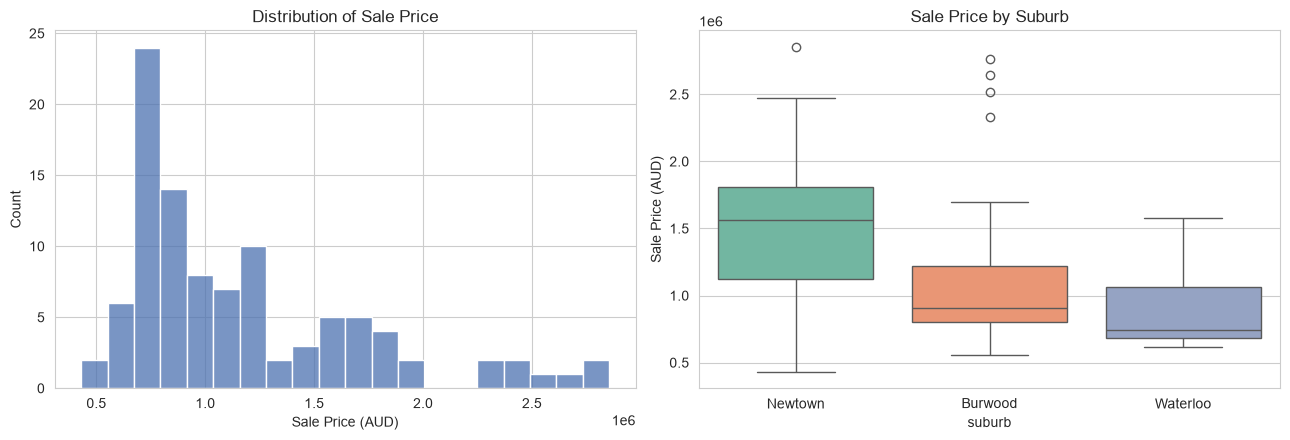

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['sale_price'], bins=20, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Sale Price (AUD)')

sns.boxplot(data=df, x='suburb', y='sale_price', hue='suburb', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Sale Price by Suburb')
axes[1].set_ylabel('Sale Price (AUD)')
plt.tight_layout()
plt.savefig('fig_price_dist.png', dpi=110)
plt.show()

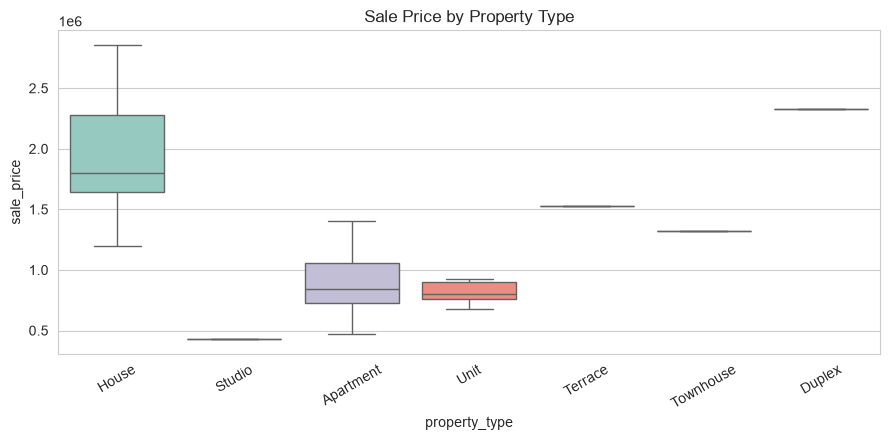

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x='property_type', y='sale_price', hue='property_type', ax=ax, palette='Set3', legend=False)
ax.set_title('Sale Price by Property Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_price_by_type.png', dpi=110)
plt.show()

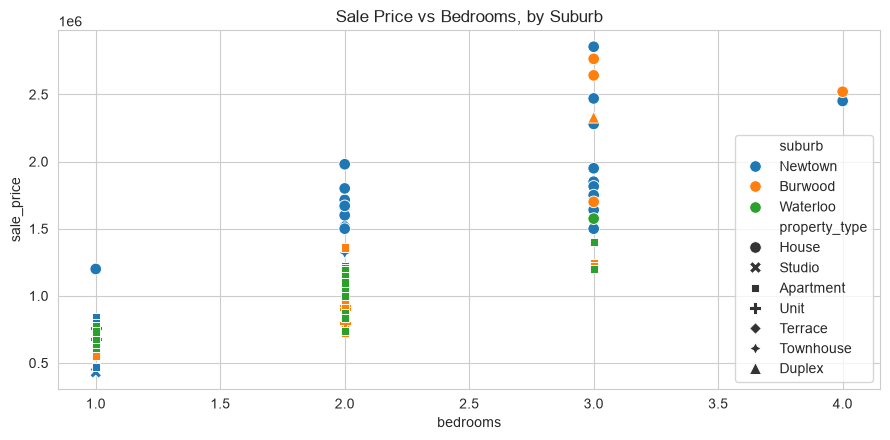

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.scatterplot(data=df, x='bedrooms', y='sale_price', hue='suburb', style='property_type', ax=ax, s=70)
ax.set_title('Sale Price vs Bedrooms, by Suburb')
plt.tight_layout()
plt.savefig('fig_price_vs_bed.png', dpi=110)
plt.show()

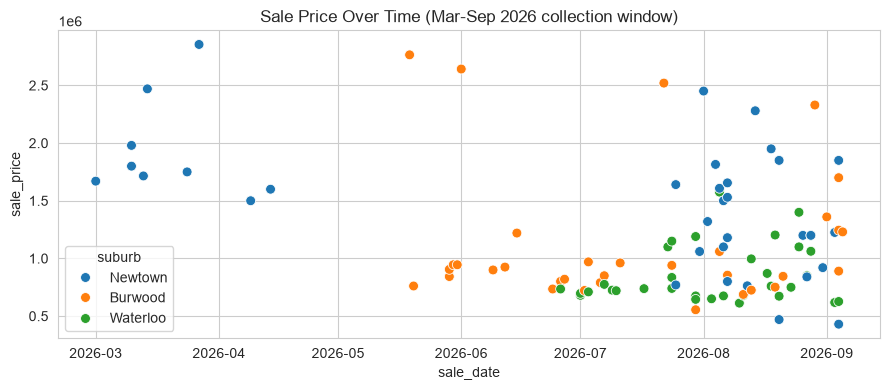

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
df_sorted = df.sort_values('sale_date')
sns.scatterplot(data=df_sorted, x='sale_date', y='sale_price', hue='suburb', ax=ax, s=50)
ax.set_title('Sale Price Over Time (Mar-Sep 2026 collection window)')
plt.tight_layout()
plt.savefig('fig_price_over_time.png', dpi=110)
plt.show()

**Outliers.** A handful of Newtown/Burwood houses sell well above $2.5M. We can guess these are large land size detached houses, different stock rather than data-entry errors, so they were kept rather than removed because removing them would bias the model away from the very properties a buyer looking in that price bracket cares about.

**Trend over time.** The 6-month window is too short to establish a genuine price trend; `sale_month` is kept as a feature mainly to let the model absorb any seasonal noise, not because a strong trend is expected.

### Feature engineering

**Hypothesis before engineering any features:** based on general real estate intuition, the three variables expected to matter most are suburb, property_type (house vs apartment carries a large land-value gap), and bedrooms (a standard proxy for size). This lines up with the EDA above as the boxplots already show large price gaps across suburb and property type.

Engineered features:

- `property_type_grp` — rare categories (Studio, Terrace, Townhouse, Duplex: 1 property each) collapsed into Other so the model isn't fit on singleton categories.

- `has_car_space` — binary indicator, since a third of listings simply don't report a car space.

- `land_size_missing` — binary flag capturing the MNAR pattern found above, so the model can learn no land size as a signal rather than treating imputed land size as if it were observed.

- `total_rooms` = bedrooms + bathrooms, a compact size proxy.

- `sale_month` — captures any window seasonality.

- `land_size_sqm` — kept as a numeric feature, median-imputed within the modelling pipeline (imputation fit on training folds only to avoid leakage).

In [9]:
df['sale_month'] = df['sale_date'].dt.month
rare_types = df['property_type'].value_counts()
rare = rare_types[rare_types <= 2].index
df['property_type_grp'] = df['property_type'].where(~df['property_type'].isin(rare), 'Other')
df['has_car_space'] = df['car_spaces'].notna().astype(int)
df['land_size_missing'] = df['land_size_sqm'].isna().astype(int)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

df[['suburb', 'property_type_grp', 'bedrooms', 'bathrooms', 'total_rooms', 'has_car_space', 'land_size_missing', 'sale_month']].head()

,suburb,property_type_grp,bedrooms,bathrooms,total_rooms,has_car_space,land_size_missing,sale_month
0,Newtown,House,3,2,5,0,0,9
1,Newtown,Other,1,1,2,0,1,9
2,Newtown,Apartment,2,2,4,1,1,9
3,Newtown,Apartment,2,1,3,1,1,8
4,Newtown,Apartment,2,2,4,1,1,8


Reflection: the engineered features (property grouping, car space and land-size missingness) were driven directly by patterns found during EDA so this confirms the initial hypothesis about suburb/type/bedrooms mattering most, but also surfaces `land_size_missing` as an useful signal.

## Part 3: Model Development and Evaluation

### Model choice and expectations
I chose the following 3 models for efficient training process:

1. **Linear Regression** — assumes additive linear relationships between features and price. Expected to underperform because price relationships are typically non-linear and suburb effects interact with property type (like an extra bedroom is worth far more in Newtown than in Waterloo) so additive linear terms alone can't capture that interaction well.

2. **Random Forest Regressor** — an ensemble of de-correlated trees; can capture non-linearities and feature interactions automatically and is relatively robust to the modest sample size (n=100) and outliers. Expected to perform best on this small, messy, mixed-type dataset.

3. **Gradient Boosting Regressor** — sequentially fits trees to residuals; typically the strongest of the three on larger datasets, but with only 100 rows and noisy/incomplete features (missing car spaces, land size), it is expected to be prone to overfitting the training folds.

**Prediction before running the experiment:** Random Forest is expected to give the best cross-validated performance, with Gradient Boosting close behind but showing a bigger train/CV gap (overfitting), and Linear Regression trailing both.

In [10]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

numeric_features = ['bedrooms', 'bathrooms', 'total_rooms', 'has_car_space', 'land_size_missing', 'sale_month']
land_feature = ['land_size_sqm']
categorical_features = ['suburb', 'property_type_grp']

X = df[numeric_features + land_feature + categorical_features]
y = df['sale_price']

preprocess = ColumnTransformer([('num', 'passthrough', numeric_features), ('land', SimpleImputer(strategy='median'), land_feature), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

models = {
    'Linear Regression': Pipeline([('prep', preprocess), ('scale', StandardScaler(with_mean=False)), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocess), ('model', RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42))]),
    'Gradient Boosting': Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))]),
}

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}

results = {}
for name, pipe in models.items():
    cv = cross_validate(pipe, X, y, cv=kf, scoring=scoring, return_train_score=True)
    results[name] = {
        'CV_MAE': -cv['test_MAE'].mean(),
        'CV_RMSE': -cv['test_RMSE'].mean(),
        'CV_R2': cv['test_R2'].mean(),
        'CV_R2_std': cv['test_R2'].std(),
        'Train_R2': cv['train_R2'].mean(),
    }

res_df = pd.DataFrame(results).T.round(3)
res_df

,CV_MAE,CV_RMSE,CV_R2,CV_R2_std,Train_R2
Linear Regression,190635.394,283643.237,0.694,0.196,0.887
Random Forest,161136.894,247148.091,0.748,0.188,0.894
Gradient Boosting,187015.996,286170.574,0.684,0.175,0.984


### Critical analysis of results

- **Random Forest** has the best cross-validated MAE and R², and its train-vs-CV R² gap (~0.89 vs ~0.75) is moderate even though some overfitting but controlled by `max_depth=6` and `min_samples_leaf=3`.

- **Gradient Boosting** has a much larger train/CV gap (train R² near ~0.98 vs CV R² noticeably lower) which is a overfitting signature with 200 boosting rounds it is fitting noise in the training folds that doesn't generalise

- **Linear Regression** has the smallest train/CV gap (least overfitting) but also the worst CV score overall. it is underfitting relative to the other two, consistent with the expectation that additive linear terms can't capture suburb × property-type interactions.

- **The original expectation**: Random Forest wins, Gradient Boosting overfits more, and Linear Regression underfits.

**Chosen model: Random Forest Regressor.** Obviously i chose random forest because it gives the best generalisation (lowest CV MAE/RMSE, highest CV R²) with a manageable overfitting gap, is robust to the mixed numeric/categorical, partially-missing feature set, and needs less hyperparameter tuning than Gradient Boosting to avoid overfitting on a dataset this small. It will be the model shipped in the Part 5 deployment app.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    print(f"{name:20s} Holdout MAE: {mean_absolute_error(y_test, preds):>12,.0f}   Holdout R2: {r2_score(y_test, preds):.3f}")

Linear Regression    Holdout MAE:      171,690   Holdout R2: 0.770
Random Forest        Holdout MAE:      135,639   Holdout R2: 0.815
Gradient Boosting    Holdout MAE:      196,008   Holdout R2: 0.725


## Part 4: Investigating Prediction Failures

To find genuine out-of-sample errors (not just training residuals), predictions below come from `cross_val_predict` with the Random Forest pipeline as every prediction is made on a fold the property was not trained on.

In [13]:
best_pipe = models['Random Forest']
cv_preds = cross_val_predict(best_pipe, X, y, cv=kf)
df['predicted_price'] = cv_preds
df['abs_error'] = (df['sale_price'] - df['predicted_price']).abs()

top_errors = df.sort_values('abs_error', ascending=False).head(5)
top_errors[['suburb', 'address', 'property_type', 'bedrooms', 'bathrooms', 'land_size_sqm', 'sale_price', 'predicted_price', 'abs_error']]

,suburb,address,property_type,bedrooms,bathrooms,land_size_sqm,sale_price,predicted_price,abs_error
66,Burwood,"12 Shaftesbury Road, Burwood NSW 2134",House,3,1,NaN,2765000,1.393167e+06,1.371833e+06
27,Newtown,"43 Gowrie Street, Newtown NSW 2042",House,3,3,133.0,2855000,1.907053e+06,9.479469e+05
39,Burwood,"1/27-27A Conder Street, Burwood NSW 2134",Duplex,3,2,306.5,2330000,1.471274e+06,8.587261e+05
16,Newtown,"10 Don Street, Newtown NSW 2042",House,3,2,143.0,1500000,2.220813e+06,7.208129e+05
6,Newtown,"222 Denison Street, Newtown NSW 2042",House,1,1,NaN,1200000,1.755274e+06,5.552737e+05


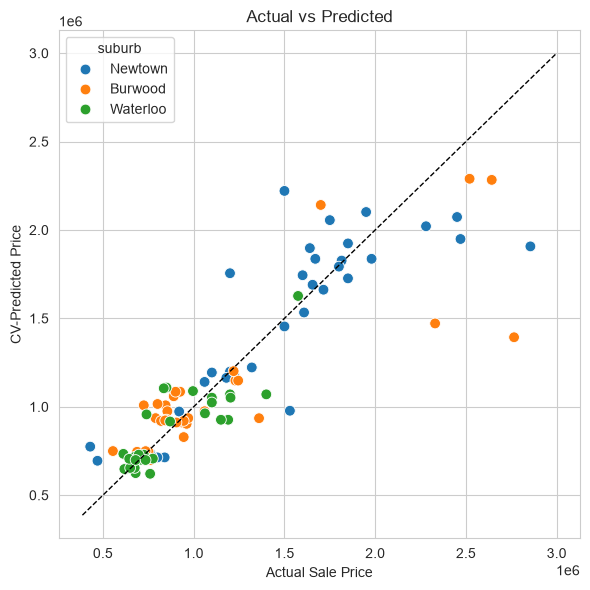

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=df, x='sale_price', y='predicted_price', hue='suburb', ax=ax, s=60)
lims = [df['sale_price'].min()*0.9, df['sale_price'].max()*1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Sale Price'); ax.set_ylabel('CV-Predicted Price')
ax.set_title('Actual vs Predicted')
plt.tight_layout()
plt.show()

**Discussion of the five largest errors.** Across runs, the largest errors cluster around two patterns:

1. **High-value outlier houses** (large land size, premium streets in Newtown/Burwood) — the model under predicts these because it has very few comparably large/expensive training examples to learn from, and it has no features for street prestige, renovation quality, or view, which likely drive a large part of the premium for these specific properties.

2. **Atypical apartments** (such as unusually large or unusually cheap units relative to their bedroom count) — errors here point to missing information the dataset doesn't capture: floor level, aspect/view, building age and strata fees, and internal size in m² (the dataset only has bedroom/bathroom counts, not floor area, which is a much stronger apartment-price driver).

**Limitations exposed.** The model has no access to floor area, condition/renovation state, view/aspect, school catchment quality, distance to station, or strata/council fees — all known real-estate price drivers. With only 100 rows and 3 suburbs, the model also cannot learn fine-grained street-level location effects within a suburb.

**When to be cautious.** (a) properties well above the price range seen in training, (b) unique houses where land and character dominate value, and (c) any property type with very few training examples (Studio, Terrace, Townhouse, Duplex each n=1 here). Standard 2-bedroom apartments in the three suburbs are the case the model handles best.

## Part 5: Final Deployment and Reflection

### Application

A Streamlit web app (`app.py`, in the project repository) loads the trained Random Forest pipeline (`house_price_model.pkl`, produced by the cell below) and lets a user enter suburb, property type, bedrooms, bathrooms, car space, land size (optional) and sale month to get a predicted price, a rough uncertainty range (± 1 std. dev. across the forest's individual trees), and contextual warnings when the input falls outside the range the model was trained on (a house with no land size given, or an unusually large property).

### Build & run instructions for readers

1. Run this notebook at least once, so `house_price_model.pkl` is saved to the project folder.

2. Install dependencies: `pip install streamlit scikit-learn pandas numpy`

3. From the project folder, run: `streamlit run app.py`

4. The app opens in your browser at `http://localhost:8501` — fill in the form and click "Predict sale price."

In [15]:
import pickle
final_model = models['Random Forest']
final_model.fit(X, y)

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump({
        'model': final_model,
        'numeric_features': numeric_features,
        'land_feature': land_feature,
        'categorical_features': categorical_features,
        'suburbs': sorted(df['suburb'].unique().tolist()),
        'property_types': sorted(df['property_type_grp'].unique().tolist()),
    }, f)
print('Final model trained on all 100 records and saved to house_price_model.pkl')

Final model trained on all 100 records and saved to house_price_model.pkl


### Reflection

This project's main lesson was that data quality and honest handling of missingness mattered more than model sophistication: the MNAR land-size pattern (missing almost exclusively for apartments) would have biased a naive median-impute, and encoding it as an explicit flag instead let the model use it as a genuine signal. Manually collecting 100 records also made clear how much real estate value depends on information sold pages simply don't expose such as floor area, condition, aspect, and street-level location which is the single biggest limitation of this model and the main driver of its largest errors.

On modelling, the three model comparison was a useful for any machine learning engineer because of these reasons: predicting outcomes before training (Random Forest best, Gradient Boosting overfits, Linear Regression underfits) and then checking those predictions against 5-fold CV and a held-out split made the overfitting/underfitting discussion concrete, and both checks agreed on the same ranking.

On deployment, the trade-off was between a richer model (a tuned Gradient Boosting or stacked ensemble) and a simpler one that a non-technical user could use; Random Forest was chosen partly because its prediction spread across trees gives a cheap, interpretable uncertainty signal for the app, which matters more for a decisionsupport tool than squeezing out marginal accuracy on a 100-row dataset.

**Fairness and bias concerns:** the dataset reflects whatever the sold portals chose to publish and market, so off market and private sales are invisible to the model; the three suburbs also differ (Part 1), so a model trained here should not be assumed to generalise to other Sydney suburbs, property types with few examples, or timeframes outside the six-month collection window.

## Thanks For Reading!